# Who Pollutes, Who Pays?
## Data Preprocessing & Integration Notebook

**Central question:** Do wealthier nations systematically emit more GHG per capita? And are low-emission countries 'green by choice' or 'green by poverty'?

**Datasets:**
1. `OECD GHG Emissions`: GHG per capita (kg CO₂-eq/person), 99 countries, 1988–2023  
2. `World Bank Economy & Growth`: GDP per capita (PPP, current intl $), 265 countries, 1960–2020  
3. `World Bank Energy & Mining`: Renewable energy share (%), electricity access (%), 265 countries, 1960–2020  

**Join key:** ISO-3 country code  
**Analysis window:** 2014–2020 (overlap of all three datasets)

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Raw Datasets

In [2]:
# OECD GHG Emissions 
GHG_PATH = 'data/OECD.csv'

ghg_raw = pd.read_csv(GHG_PATH)
print(f'GHG raw shape: {ghg_raw.shape}')
print(f'Columns: {ghg_raw.columns.tolist()}')
ghg_raw.head(3)

GHG raw shape: (2723, 30)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'FREQ', 'Frequency of observation', 'POLLUTANT', 'Pollutant', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'PRICE_BASE', 'Price base', 'BASE_PER', 'Base period', 'DECIMALS', 'Decimals', 'CONVERSION_TYPE', 'Conversion type']


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,FREQ,Frequency of observation,POLLUTANT,Pollutant,MEASURE,Measure,UNIT_MEASURE,Unit of measure,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,PRICE_BASE,Price base,BASE_PER,Base period,DECIMALS,Decimals,CONVERSION_TYPE,Conversion type
0,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,AUS,Australia,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,19.93,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
1,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,AUT,Austria,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,7.52,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN
2,DATAFLOW,OECD.ENV.EPI:DSD_AIR_GHG@DF_AIR_GHG(1.0),Air emissions - Greenhouse gas emissions Inven...,I,BEL,Belgium,A,Annual,GHG,Greenhouse gases,_T,Total emissions excluding LULUCF,KG_CO2E_PS,Kilogrammes of CO2-equivalent per person,2023,NaN,8.39,NaN,A,Normal value,3,Thousands,NaN,NaN,NaN,NaN,2,Two,NaN,NaN


In [3]:
# World Bank Economy & Growth
eco_raw = pd.read_csv('data/economy-and-growth.csv')
print(f'Economy raw shape: {eco_raw.shape}')
print(f'Year range: {eco_raw["Year"].min()} – {eco_raw["Year"].max()}')
eco_raw.head(3)

Economy raw shape: (15585, 53)
Year range: 1960 – 2020


,Country Name,Country Code,Year,average_value_DEC alternative conversion factor (LCU per US$),average_value_Discrepancy in expenditure estimate of GDP (current LCU),average_value_GDP (constant 2010 US$),average_value_GDP (constant LCU),average_value_GDP (current LCU),average_value_GDP (current US$),average_value_GDP deflator (base year varies by country),average_value_GDP growth (annual %),average_value_GDP per capita (constant 2010 US$),average_value_GDP per capita (constant LCU),average_value_GDP per capita (current LCU),average_value_GDP per capita (current US$),...,average_value_Gross savings (current LCU),average_value_Gross savings (current US$),average_value_Gross value added at basic prices (GVA) (constant LCU),average_value_Gross value added at basic prices (GVA) (current LCU),average_value_Gross value added at basic prices (GVA) (current US$),average_value_Net primary income (Net income from abroad) (current LCU),average_value_Net primary income (Net income from abroad) (current US$),average_value_Net secondary income (Net current transfers from abroad) (current LCU),average_value_Net secondary income (Net current transfers from abroad) (current US$),"average_value_PPP conversion factor, GDP (LCU per international $)","average_value_PPP conversion factor, private consumption (LCU per international $)",average_value_Price level ratio of PPP conversion factor (GDP) to market exchange rate,average_value_Taxes less subsidies on products (constant LCU),average_value_Taxes less subsidies on products (current LCU),average_value_Taxes less subsidies on products (current US$)
0,Arab World,ARB,1988,NaN,NaN,822211133754.53,NaN,NaN,421921035099.97,NaN,5.65,3936.10,NaN,NaN,2019.83,...,NaN,NaN,NaN,NaN,449861580220.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,United Arab Emirates,ARE,1966,4.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Antigua and Barbuda,ATG,1962,1.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# World Bank Energy & Mining 
nrg_raw = pd.read_csv('data/energy-and-mining.csv')
print(f'Energy raw shape: {nrg_raw.shape}')
print(f'Year range: {nrg_raw["Year"].min()} – {nrg_raw["Year"].max()}')
nrg_raw.head(3)

Energy raw shape: (15535, 53)
Year range: 1960 – 2020


,Country Name,Country Code,Year,average_value_Access to electricity (% of population),"average_value_Access to electricity, rural (% of rural population)","average_value_Access to electricity, urban (% of urban population)",average_value_Adjusted savings: energy depletion (% of GNI),average_value_Adjusted savings: energy depletion (current US$),average_value_Adjusted savings: mineral depletion (% of GNI),average_value_Adjusted savings: mineral depletion (current US$),average_value_Adjusted savings: natural resources depletion (% of GNI),average_value_Alternative and nuclear energy (% of total energy use),average_value_CO2 emissions from gaseous fuel consumption (% of total),average_value_CO2 emissions from liquid fuel consumption (kt),average_value_Combustible renewables and waste (% of total energy),...,average_value_Mineral rents (% of GDP),average_value_Natural gas rents (% of GDP),average_value_Nitrous oxide emissions in energy sector (% of total),average_value_Nitrous oxide emissions in energy sector (thousand metric tons of CO2 equivalent),average_value_Oil rents (% of GDP),average_value_Ores and metals exports (% of merchandise exports),average_value_Ores and metals imports (% of merchandise imports),average_value_Pump price for diesel fuel (US$ per liter),average_value_Pump price for gasoline (US$ per liter),average_value_Renewable electricity output (% of total electricity output),average_value_Renewable energy consumption (% of total final energy consumption),average_value_Time required to get electricity (days),average_value_Time to obtain an electrical connection (days),average_value_Total natural resources rents (% of GDP),average_value_Value lost due to electrical outages (% of sales for affected firms)
0,Africa Eastern and Southern,AFE,1987,NaN,NaN,NaN,1.34,NaN,1.32,NaN,4.12,2.11,0.08,73479.52,44.94,...,2.41,0.00,2.16,5762.79,0.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.03,NaN
1,Albania,ALB,2019,100.00,100.00,100.00,0.83,124687724.86,0.01,1783616.76,0.87,NaN,NaN,NaN,NaN,...,0.03,0.02,NaN,NaN,1.35,NaN,NaN,NaN,NaN,NaN,NaN,71.00,18.60,1.59,1.90
2,Albania,ALB,1977,NaN,NaN,NaN,NaN,70677019.42,NaN,6867636.58,NaN,8.15,12.24,2948.27,16.15,...,NaN,NaN,3.71,37.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean OECD GHG Dataset

**Key choices:**
- Keep only `MEASURE == '_T'` (total emissions excl. LULUCF) and `UNIT_MEASURE == 'KG_CO2E_PS'` (kg CO₂-eq per person)
- Drop aggregate/supranational entities (EU27, OECD, etc.) --> they are not countries
- Rename columns to clean, short names
- Filter to 2014–2023 (the decade of interest)

In [5]:
# Supranational aggregates to exclude
AGGREGATES = {'EU27_2020', 'OECD', 'OECDA', 'OECDSO', 'OECDE'}

ghg = (
    ghg_raw
    # Keep only the per-capita total GHG measure
    .query("MEASURE == '_T' and UNIT_MEASURE == 'KG_CO2E_PS'")
    # Drop supranational aggregates
    .loc[lambda df: ~df['REF_AREA'].isin(AGGREGATES)]
    # Select and rename relevant columns
    [['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
    .rename(columns={
        'REF_AREA': 'iso3',
        'Reference area': 'country_name_ghg',
        'TIME_PERIOD': 'year',
        'OBS_VALUE': 'ghg_per_capita'
    })
    # Filter to 2014–2023
    .query('year >= 2014 and year <= 2023')
    .dropna(subset=['ghg_per_capita'])
    .reset_index(drop=True)
)

print(f'GHG cleaned shape: {ghg.shape}')
print(f'Countries: {ghg["iso3"].nunique()}')
print(f'Years: {sorted(ghg["year"].unique())}')
ghg.head()

GHG cleaned shape: (789, 4)
Countries: 90
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


,iso3,country_name_ghg,year,ghg_per_capita
0,AUS,Australia,2023,19.93
1,AUT,Austria,2023,7.52
2,BEL,Belgium,2023,8.39
3,CAN,Canada,2023,17.66
4,CZE,Czechia,2023,9.44


In [6]:
# Quick check: missing values
print('GHG missing values:')
print(ghg.isnull().sum())

# Summary stats
print('\nGHG per capita descriptive stats:')
print(ghg['ghg_per_capita'].describe())

GHG missing values:
iso3                0
country_name_ghg    0
year                0
ghg_per_capita      0
dtype: int64

GHG per capita descriptive stats:
count   789.00
mean      7.99
std       5.66
min       0.69
25%       4.49
50%       6.67
75%       9.79
max      33.77
Name: ghg_per_capita, dtype: float64


## 3. Clean World Bank Economy Dataset

**Key variable selected:** `GDP per capita, PPP (current international $)` —-> chosen over nominal GDP/capita because PPP adjusts for price-level differences, making cross-country comparisons more meaningful for living-standard analysis.

**Key choices:**
- Filter to 2014–2020 (overlap window)
- Drop World Bank regional/income-group aggregates (they share no ISO-3 code with GHG countries)
- Keep only rows with non-missing GDP per capita PPP

In [7]:
GDP_COL = 'average_value_GDP per capita, PPP (current international $)'

eco = (
    eco_raw
    [['Country Name', 'Country Code', 'Year', GDP_COL]]
    .rename(columns={
        'Country Name': 'country_name_wb',
        'Country Code': 'iso3',
        'Year': 'year',
        GDP_COL: 'gdp_per_capita_ppp'
    })
    .query('year >= 2014 and year <= 2020')
    .dropna(subset=['gdp_per_capita_ppp'])
    .reset_index(drop=True)
)

print(f'Economy cleaned shape: {eco.shape}')
print(f'Countries: {eco["iso3"].nunique()}')
print(f'Years: {sorted(eco["year"].unique())}')
eco.head()

Economy cleaned shape: (1676, 4)
Countries: 243
Years: [2014, 2015, 2016, 2017, 2018, 2019, 2020]


,country_name_wb,iso3,year,gdp_per_capita_ppp
0,Belgium,BEL,2018,52662.53
1,Canada,CAN,2017,48317.10
2,"Egypt, Arab Rep.",EGY,2019,12260.72
3,Guinea-Bissau,GNB,2019,2021.30
4,"Hong Kong SAR, China",HKG,2016,57221.41


In [8]:
print('Economy missing values after filter:')
print(eco.isnull().sum())
print('\nGDP per capita PPP stats:')
print(eco['gdp_per_capita_ppp'].describe())

Economy missing values after filter:
country_name_wb       0
iso3                  0
year                  0
gdp_per_capita_ppp    0
dtype: int64

GDP per capita PPP stats:
count     1676.00
mean     20012.11
std      20811.24
min        720.32
25%       4683.49
50%      13064.42
75%      27865.26
max     152856.34
Name: gdp_per_capita_ppp, dtype: float64


## 4. Clean World Bank Energy Dataset

**Key variables selected:**
- `Renewable energy consumption (% of total final energy consumption)` —-> proxy for clean energy transition
- `Access to electricity (% of population)` —-> proxy for energy poverty
- `Fossil fuel energy consumption (% of total)` —-> complementary to renewable share

Same temporal filter: 2014–2020.

In [9]:
RENEW_COL   = 'average_value_Renewable energy consumption (% of total final energy consumption)'
ELEC_COL    = 'average_value_Access to electricity (% of population)'
FOSSIL_COL  = 'average_value_Fossil fuel energy consumption (% of total)'

nrg = (
    nrg_raw
    [['Country Name', 'Country Code', 'Year', RENEW_COL, ELEC_COL, FOSSIL_COL]]
    .rename(columns={
        'Country Name': 'country_name_wb',
        'Country Code': 'iso3',
        'Year': 'year',
        RENEW_COL:  'renewable_pct',
        ELEC_COL:   'electricity_access_pct',
        FOSSIL_COL: 'fossil_fuel_pct'
    })
    .query('year >= 2014 and year <= 2020')
    .reset_index(drop=True)
)

print(f'Energy cleaned shape: {nrg.shape}')
print(f'Countries: {nrg["iso3"].nunique()}')
nrg.head()

Energy cleaned shape: (1707, 6)
Countries: 265


,country_name_wb,iso3,year,renewable_pct,electricity_access_pct,fossil_fuel_pct
0,Albania,ALB,2019,NaN,100.00,NaN
1,Armenia,ARM,2020,NaN,NaN,NaN
2,Azerbaijan,AZE,2015,2.31,100.00,NaN
3,China,CHN,2014,12.06,100.00,87.67
4,Isle of Man,IMN,2017,1.88,100.00,NaN


In [10]:
print('Energy missing values (per column):')
print(nrg.isnull().sum())
print()

# How many country-year pairs have at least one energy variable?
nrg_any = nrg.dropna(subset=['renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct'], how='all')
print(f'Country-year pairs with ≥1 energy value: {len(nrg_any)}')

Energy missing values (per column):
country_name_wb              0
iso3                         0
year                         0
renewable_pct              546
electricity_access_pct     123
fossil_fuel_pct           1467
dtype: int64

Country-year pairs with ≥1 energy value: 1589


## 5. Add World Bank Region / Continent Metadata

The `continent` / macro-region variable is **not present in any raw dataset** and must be constructed externally.

We use the World Bank's official 7-region classification, embedded here as a static mapping to avoid any external API dependency. The mapping covers all ISO-3 codes present in the GHG dataset.

In [11]:
# World Bank 7-region classification (manually curated for GHG countries)
# Source: https://datahelpdesk.worldbank.org/knowledgebase/articles/906519
WB_REGION = {
    # Europe & Central Asia
    'AUT': 'Europe & Central Asia', 'BEL': 'Europe & Central Asia',
    'CZE': 'Europe & Central Asia', 'DNK': 'Europe & Central Asia',
    'EST': 'Europe & Central Asia', 'FIN': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia', 'DEU': 'Europe & Central Asia',
    'GRC': 'Europe & Central Asia', 'HUN': 'Europe & Central Asia',
    'ISL': 'Europe & Central Asia', 'IRL': 'Europe & Central Asia',
    'ITA': 'Europe & Central Asia', 'LVA': 'Europe & Central Asia',
    'LTU': 'Europe & Central Asia', 'LUX': 'Europe & Central Asia',
    'NLD': 'Europe & Central Asia', 'NOR': 'Europe & Central Asia',
    'POL': 'Europe & Central Asia', 'PRT': 'Europe & Central Asia',
    'SVK': 'Europe & Central Asia', 'SVN': 'Europe & Central Asia',
    'ESP': 'Europe & Central Asia', 'SWE': 'Europe & Central Asia',
    'CHE': 'Europe & Central Asia', 'GBR': 'Europe & Central Asia',
    'AZE': 'Europe & Central Asia', 'BLR': 'Europe & Central Asia',
    'TUR': 'Europe & Central Asia',
    # North America
    'CAN': 'North America', 'MEX': 'North America', 'USA': 'North America',
    # Latin America & Caribbean
    'ARG': 'Latin America & Caribbean', 'BRB': 'Latin America & Caribbean',
    'CHL': 'Latin America & Caribbean', 'COL': 'Latin America & Caribbean',
    'CRI': 'Latin America & Caribbean',
    # East Asia & Pacific
    'AUS': 'East Asia & Pacific', 'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific', 'NZL': 'East Asia & Pacific',
    'BTN': 'East Asia & Pacific',
    # South Asia
    # (none in GHG sample)
    # Middle East & North Africa
    'ISR': 'Middle East & North Africa', 'DZA': 'Middle East & North Africa',
}

# Verify coverage
ghg_countries = set(ghg['iso3'].unique())
mapped = set(WB_REGION.keys())
unmapped = ghg_countries - mapped
print(f'GHG countries: {len(ghg_countries)}')
print(f'Mapped to region: {len(mapped & ghg_countries)}')
print(f'Unmapped (will be NaN): {unmapped}')

GHG countries: 90
Mapped to region: 43
Unmapped (will be NaN): {'BRN', 'ROU', 'GHA', 'LIE', 'ZAF', 'SRB', 'CIV', 'SLB', 'MDA', 'IRQ', 'UZB', 'NPL', 'GTM', 'NGA', 'VAT', 'MYS', 'PER', 'CYP', 'SGP', 'GEO', 'NAM', 'CHN', 'URY', 'RWA', 'MLT', 'MCO', 'EGY', 'CUB', 'IND', 'BGR', 'VEN', 'SAU', 'MUS', 'GNB', 'PAN', 'THA', 'UKR', 'GUY', 'RUS', 'MAR', 'IDN', 'MDV', 'LBN', 'BRA', 'KEN', 'KAZ', 'HRV'}


In [12]:
# Add region to GHG
ghg['region'] = ghg['iso3'].map(WB_REGION)

print('Region distribution in GHG dataset:')
print(ghg.groupby('region')['iso3'].nunique().sort_values(ascending=False))

Region distribution in GHG dataset:
region
Europe & Central Asia         29
East Asia & Pacific            5
Latin America & Caribbean      4
North America                  3
Middle East & North Africa     2
Name: iso3, dtype: int64


## 6. Three-Way Join

**Strategy:**
- **Anchor:** GHG dataset (has country-year rows for 2014–2023)
- **Left join** Economy on `(iso3, year)` —-> keeps all GHG rows, adds GDP where available
- **Left join** Energy on `(iso3, year)` —-> keeps all GHG rows, adds energy vars where available
- Time window restricted to **2014–2020** for the complete 3-dataset panel
- A separate **2014–2023 GHG-only** dataframe is kept for trend visualizations

In [13]:
# 6a. Full trend dataset (GHG only, 2014–2023) 
df_trend = ghg.copy()
print(f'Trend dataset (GHG only 2014-2023): {df_trend.shape}')

# 6b. Joined panel (2014–2020) 
ghg_2020 = ghg.query('year <= 2020').copy()

# Join economy
df = ghg_2020.merge(
    eco[['iso3', 'year', 'gdp_per_capita_ppp']],
    on=['iso3', 'year'],
    how='left'
)

# Join energy
df = df.merge(
    nrg[['iso3', 'year', 'renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct']],
    on=['iso3', 'year'],
    how='left'
)

print(f'\nJoined panel shape (2014-2020): {df.shape}')
print(f'Countries with GHG data: {df["iso3"].nunique()}')
df.head()

Trend dataset (GHG only 2014-2023): (789, 5)

Joined panel shape (2014-2020): (575, 9)
Countries with GHG data: 90


,iso3,country_name_ghg,year,ghg_per_capita,region,gdp_per_capita_ppp,renewable_pct,electricity_access_pct,fossil_fuel_pct
0,AUS,Australia,2017,22.75,East Asia & Pacific,48482.65,9.69,100.00,NaN
1,AUT,Austria,2017,9.39,Europe & Central Asia,54169.96,33.96,100.00,NaN
2,BEL,Belgium,2017,10.25,Europe & Central Asia,50442.27,9.64,100.00,NaN
3,CAN,Canada,2017,20.04,North America,48317.10,22.77,100.00,NaN
4,CHL,Chile,2017,5.70,Latin America & Caribbean,24470.70,24.11,99.70,NaN


In [14]:
# Missing value audit on the joined panel
print('Missing values in joined panel:')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
audit = pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct})
print(audit[audit['missing_n'] > 0])

Missing values in joined panel:
                        missing_n  missing_%
region                        285      49.60
gdp_per_capita_ppp             36       6.30
renewable_pct                 181      31.50
electricity_access_pct         95      16.50
fossil_fuel_pct               470      81.70


In [15]:
# Countries with ALL THREE variables for at least one year in 2014-2020
complete_mask = df[['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct']].notna().all(axis=1)
complete_countries = df.loc[complete_mask, 'iso3'].nunique()
print(f'Countries with complete data (all 4 key vars) in ≥1 year: {complete_countries}')

# Country-year pairs fully complete
print(f'Fully complete country-year pairs: {complete_mask.sum()}')

Countries with complete data (all 4 key vars) in ≥1 year: 77
Fully complete country-year pairs: 379


## 7. Analytical Sample Definition

We define the **core analytical sample** as countries with complete data on all four key variables in the **2014–2020** window. These are the countries that can appear in all six linked visualizations.

Countries with partial data are retained in `df` for single-dataset visualizations (e.g., GHG trend chart, choropleth map).

In [16]:
KEY_VARS = ['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct']

# Core sample: countries with complete data in ALL years 2014-2020
country_completeness = (
    df.groupby('iso3')[KEY_VARS]
    .apply(lambda g: g.notna().all(axis=1).sum())
    .reset_index()
    .rename(columns={0: 'complete_years'})
)

# Keep countries with data for at least 5 of the 7 years
core_countries = country_completeness.loc[
    country_completeness['complete_years'] >= 5, 'iso3'
].tolist()

print(f'Core analytical sample (≥5 complete years): {len(core_countries)} countries')

df_core = df[df['iso3'].isin(core_countries)].copy()
print(f'Core panel shape: {df_core.shape}')

Core analytical sample (≥5 complete years): 75 countries
Core panel shape: (525, 9)


In [17]:
# Region distribution in core sample
core_regions = df_core.drop_duplicates('iso3')[['iso3', 'region']]
print('Core sample by region:')
print(core_regions['region'].value_counts())

Core sample by region:
region
Europe & Central Asia         28
East Asia & Pacific            4
Latin America & Caribbean      4
North America                  3
Middle East & North Africa     2
Name: count, dtype: int64


## 8. Derived Variables

We compute additional variables needed by specific visualizations:

- **`ghg_change_pct`**: % change in GHG per capita from 2014 to 2023 (for slope chart / trend viz, uses `df_trend`)
- **`log_gdp`**: log₁₀ of GDP per capita PPP (linearizes the wealth–emissions scatter)
- **`energy_poverty_flag`**: binary flag —-> country has low electricity access (<85%) AND low GHG per capita (< global median)
- **`green_by_choice_flag`**: low GHG (<median) AND high renewables (>median)

In [18]:
# 8a. GHG trend change 2014→2023 
ghg_2014 = df_trend[df_trend['year'] == 2014][['iso3', 'ghg_per_capita']].rename(columns={'ghg_per_capita': 'ghg_2014'})
ghg_2023 = df_trend[df_trend['year'] == 2023][['iso3', 'ghg_per_capita']].rename(columns={'ghg_per_capita': 'ghg_2023'})

df_slope = ghg_2014.merge(ghg_2023, on='iso3', how='inner')
df_slope['ghg_change_pct'] = ((df_slope['ghg_2023'] - df_slope['ghg_2014']) / df_slope['ghg_2014'] * 100).round(2)
df_slope['ghg_change_abs'] = (df_slope['ghg_2023'] - df_slope['ghg_2014']).round(3)

# Add country name and region
meta = ghg[['iso3', 'country_name_ghg', 'region']].drop_duplicates('iso3')
df_slope = df_slope.merge(meta, on='iso3', how='left')

print(f'Slope chart dataset: {df_slope.shape}')
print('\nTop 5 improvers (% reduction):')
print(df_slope.nsmallest(5, 'ghg_change_pct')[['iso3','country_name_ghg','ghg_2014','ghg_2023','ghg_change_pct']])
print('\nTop 5 worseners (% increase):')
print(df_slope.nlargest(5, 'ghg_change_pct')[['iso3','country_name_ghg','ghg_2014','ghg_2023','ghg_change_pct']])

Slope chart dataset: (44, 7)

Top 5 improvers (% reduction):
   iso3 country_name_ghg  ghg_2014  ghg_2023  ghg_change_pct
6   EST          Estonia     15.97      7.95          -50.24
19  LUX       Luxembourg     19.43     11.68          -39.89
38  MLT            Malta      6.55      4.21          -35.66
39  MCO           Monaco      2.35      1.53          -34.60
7   FIN          Finland     10.73      7.33          -31.68

Top 5 worseners (% increase):
   iso3 country_name_ghg  ghg_2014  ghg_2023  ghg_change_pct
42  SRB           Serbia      7.62      9.17           20.37
30  TUR          Türkiye      6.00      6.86           14.43
34  HRV          Croatia      5.76      6.52           13.30
41  RUS           Russia     13.66     14.32            4.84
17  LVA           Latvia      5.37      5.30           -1.44


In [19]:
# 8b. Log GDP & classification flags 
df_core['log_gdp'] = np.log10(df_core['gdp_per_capita_ppp'].replace(0, np.nan))

# Use 2018 as reference year for thresholds (midpoint of 2014-2020, good coverage)
ref = df_core[df_core['year'] == 2018].copy()
ghg_median  = ref['ghg_per_capita'].median()
renew_median = ref['renewable_pct'].median()
elec_threshold = 85  # WHO/World Bank standard for meaningful electricity access

print(f'2018 reference thresholds:')
print(f'  GHG per capita median:    {ghg_median:.1f} kg CO₂-eq/person')
print(f'  Renewable share median:   {renew_median:.1f}%')
print(f'  Electricity access threshold: {elec_threshold}%')

df_core['energy_poverty_flag'] = (
    (df_core['electricity_access_pct'] < elec_threshold) &
    (df_core['ghg_per_capita'] < ghg_median)
).astype(int)

df_core['green_by_choice_flag'] = (
    (df_core['ghg_per_capita'] < ghg_median) &
    (df_core['renewable_pct'] > renew_median)
).astype(int)

print('\nEnergy poverty flag distribution (core panel):')
print(df_core['energy_poverty_flag'].value_counts())
print('\nGreen by choice flag distribution:')
print(df_core['green_by_choice_flag'].value_counts())

2018 reference thresholds:
  GHG per capita median:    7.0 kg CO₂-eq/person
  Renewable share median:   17.9%
  Electricity access threshold: 85%

Energy poverty flag distribution (core panel):
energy_poverty_flag
0    475
1     50
Name: count, dtype: int64

Green by choice flag distribution:
green_by_choice_flag
0    393
1    132
Name: count, dtype: int64


## 9. Exploratory Data Analysis
(the following visualizations are not final ones that we'll present as the output of our projects, but serve to validate the data and inform design choices for the final visualizations)

### 9a. Distribution of GHG per capita (2018)

Saved: eda_ghg_distribution.png


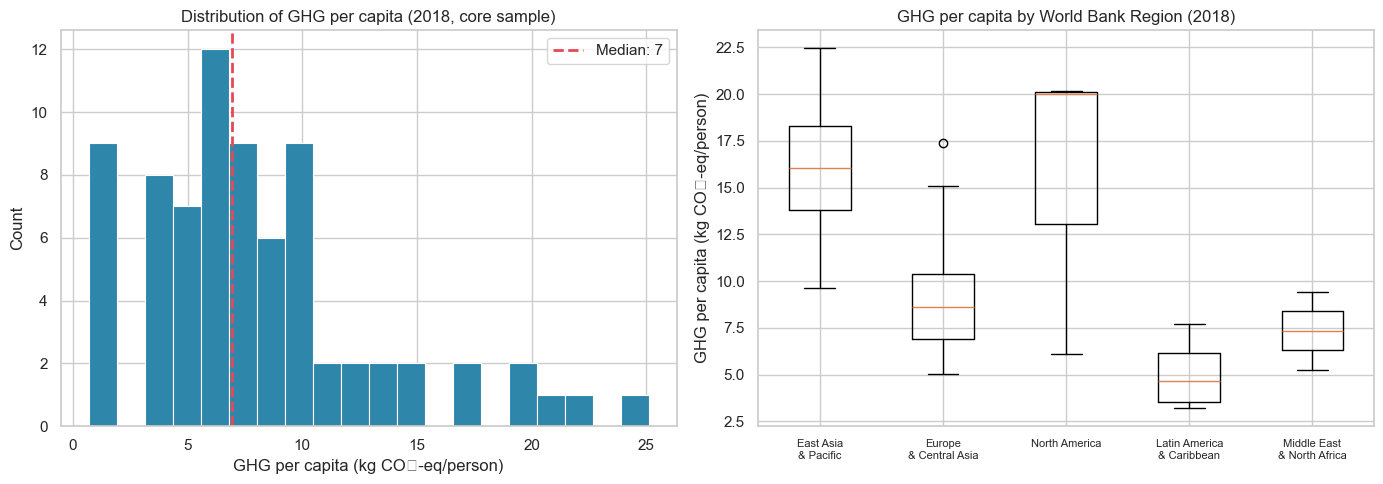

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_2018 = df_core[df_core['year'] == 2018]

# Histogram
axes[0].hist(data_2018['ghg_per_capita'].dropna(), bins=20, color='#2E86AB', edgecolor='white', linewidth=0.8)
axes[0].axvline(ghg_median, color='#E84855', linestyle='--', linewidth=2, label=f'Median: {ghg_median:.0f}')
axes[0].set_xlabel('GHG per capita (kg CO₂-eq/person)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of GHG per capita (2018, core sample)')
axes[0].legend()

# Box plot by region
regions_present = data_2018['region'].dropna().unique()
bp_data = [data_2018[data_2018['region'] == r]['ghg_per_capita'].dropna().values for r in regions_present]
axes[1].boxplot(bp_data, labels=[r.replace(' & ', '\n& ') for r in regions_present], vert=True)
axes[1].set_ylabel('GHG per capita (kg CO₂-eq/person)')
axes[1].set_title('GHG per capita by World Bank Region (2018)')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
#plt.savefig('eda_ghg_distribution.png', dpi=150, bbox_inches='tight')

print('Saved: eda_ghg_distribution.png')

### 9b. Wealth vs. Emissions Scatter (2018)

Saved: eda_scatter_gdp_ghg.png


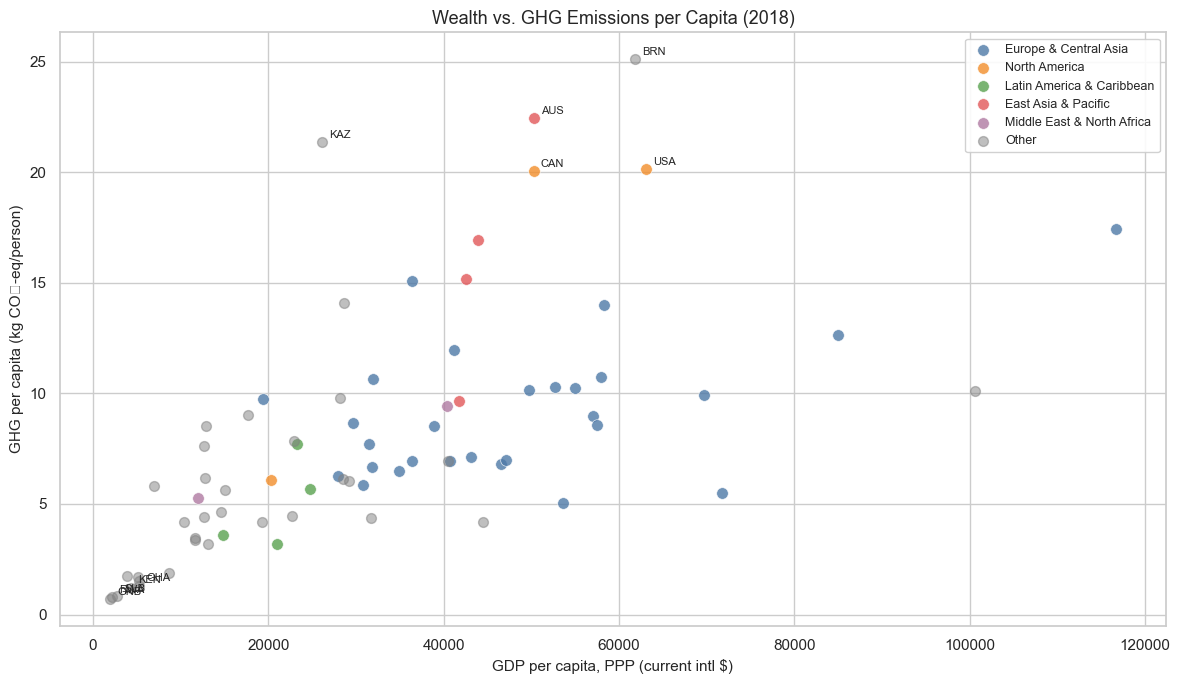

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

region_colors = {
    'Europe & Central Asia': '#4E79A7',
    'North America': '#F28E2B',
    'Latin America & Caribbean': '#59A14F',
    'East Asia & Pacific': '#E15759',
    'Middle East & North Africa': '#B07AA1',
}

for region, color in region_colors.items():
    sub = data_2018[data_2018['region'] == region]
    ax.scatter(
        sub['gdp_per_capita_ppp'], sub['ghg_per_capita'],
        c=color, label=region, alpha=0.8, s=70, edgecolors='white', linewidths=0.5
    )

# Also plot unmapped region
sub_other = data_2018[~data_2018['region'].isin(region_colors.keys())]
if len(sub_other) > 0:
    ax.scatter(sub_other['gdp_per_capita_ppp'], sub_other['ghg_per_capita'],
               c='gray', label='Other', alpha=0.5, s=50)

# Annotate outliers (top 5 emitters and 5 lowest emitters)
top5 = data_2018.nlargest(5, 'ghg_per_capita')
bot5 = data_2018.nsmallest(5, 'ghg_per_capita')
for _, row in pd.concat([top5, bot5]).iterrows():
    ax.annotate(row['iso3'], (row['gdp_per_capita_ppp'], row['ghg_per_capita']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('GDP per capita, PPP (current intl $)', fontsize=11)
ax.set_ylabel('GHG per capita (kg CO₂-eq/person)', fontsize=11)
ax.set_title('Wealth vs. GHG Emissions per Capita (2018)', fontsize=13)
ax.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
#plt.savefig('eda_scatter_gdp_ghg.png', dpi=150, bbox_inches='tight')

print('Saved: eda_scatter_gdp_ghg.png')

### 9c. GHG Trends Over Time (2014–2023, selected countries)

Saved: eda_ghg_trends.png


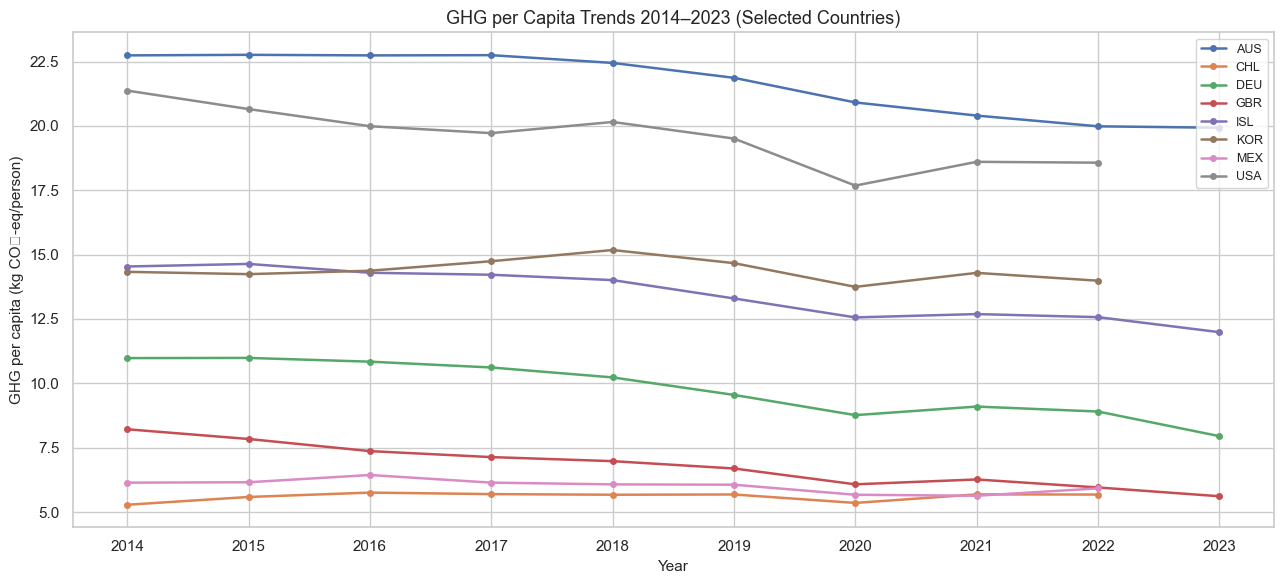

In [22]:
# Select representative countries from different regions
highlight = ['USA', 'DEU', 'GBR', 'AUS', 'CHL', 'MEX', 'KOR', 'ISL']

fig, ax = plt.subplots(figsize=(13, 6))

trend_sub = df_trend[df_trend['iso3'].isin(highlight)]

for iso, grp in trend_sub.groupby('iso3'):
    grp_sorted = grp.sort_values('year')
    ax.plot(grp_sorted['year'], grp_sorted['ghg_per_capita'], marker='o', markersize=4, label=iso, linewidth=1.8)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('GHG per capita (kg CO₂-eq/person)', fontsize=11)
ax.set_title('GHG per Capita Trends 2014–2023 (Selected Countries)', fontsize=13)
ax.set_xticks(range(2014, 2024))
ax.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('eda_ghg_trends.png', dpi=150, bbox_inches='tight')

print('Saved: eda_ghg_trends.png')

### 9d. Green by Choice vs. Energy Poverty —-> Quadrant Analysis (2018)

Saved: eda_choice_vs_poverty.png


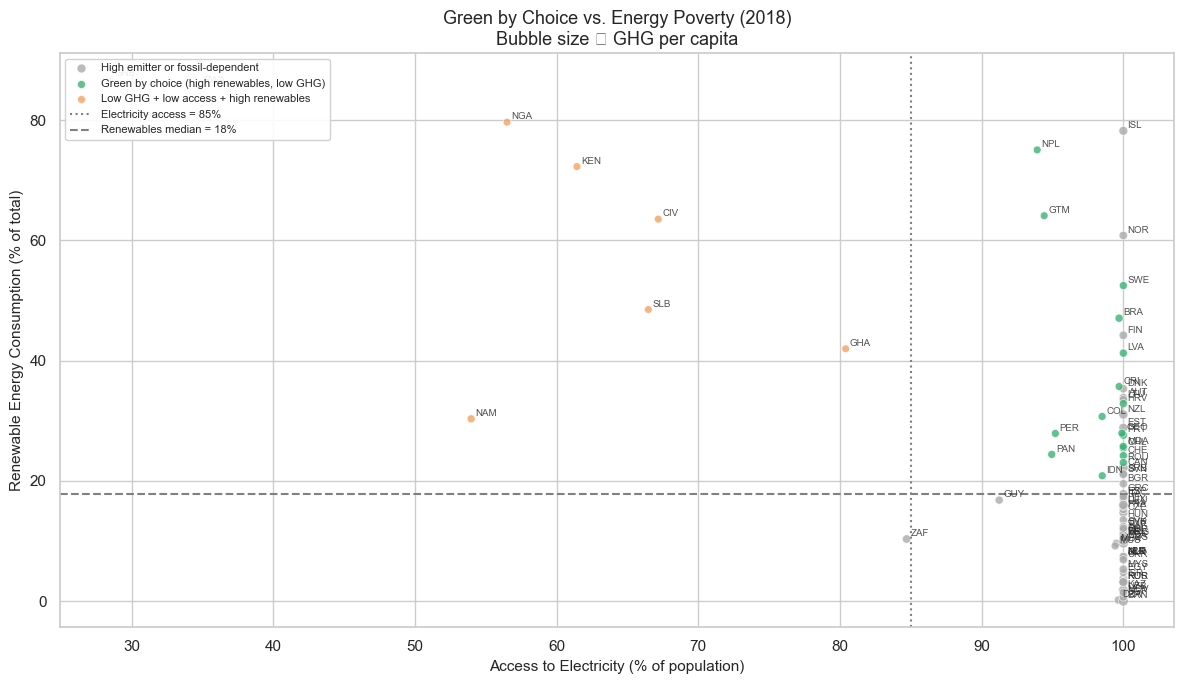

In [23]:
fig, ax = plt.subplots(figsize=(12, 7))

# Color by flag
colors_map = {
    (0, 0): '#AAAAAA',  # neither
    (1, 0): '#E84855',  # energy poverty (low elec, low GHG)
    (0, 1): '#3BB273',  # green by choice (high renew, low GHG)
    (1, 1): '#F4A261',  # both (edge case)
}
labels_map = {
    (0, 0): 'High emitter or fossil-dependent',
    (1, 0): 'Energy poverty (low access, low GHG)',
    (0, 1): 'Green by choice (high renewables, low GHG)',
    (1, 1): 'Low GHG + low access + high renewables',
}

for (ep, gc), color in colors_map.items():
    sub = data_2018[
        (data_2018['energy_poverty_flag'] == ep) &
        (data_2018['green_by_choice_flag'] == gc)
    ].dropna(subset=['electricity_access_pct', 'renewable_pct'])
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['electricity_access_pct'], sub['renewable_pct'],
        c=color, label=labels_map[(ep, gc)],
        s=sub['ghg_per_capita'] * 0.8 + 30,  # size encodes GHG
        alpha=0.8, edgecolors='white', linewidths=0.5
    )
    for _, row in sub.iterrows():
        ax.annotate(row['iso3'], (row['electricity_access_pct'], row['renewable_pct']),
                    fontsize=7, xytext=(3, 2), textcoords='offset points', alpha=0.8)

ax.axvline(elec_threshold, color='gray', linestyle=':', linewidth=1.5, label=f'Electricity access = {elec_threshold}%')
ax.axhline(renew_median, color='gray', linestyle='--', linewidth=1.5, label=f'Renewables median = {renew_median:.0f}%')

ax.set_xlabel('Access to Electricity (% of population)', fontsize=11)
ax.set_ylabel('Renewable Energy Consumption (% of total)', fontsize=11)
ax.set_title('Green by Choice vs. Energy Poverty (2018)\nBubble size ∝ GHG per capita', fontsize=13)
ax.legend(fontsize=8, framealpha=0.9, loc='upper left')

plt.tight_layout()
#plt.savefig('eda_choice_vs_poverty.png', dpi=150, bbox_inches='tight')

print('Saved: eda_choice_vs_poverty.png')

## 10. Correlation Matrix

Saved: eda_correlation_matrix.png


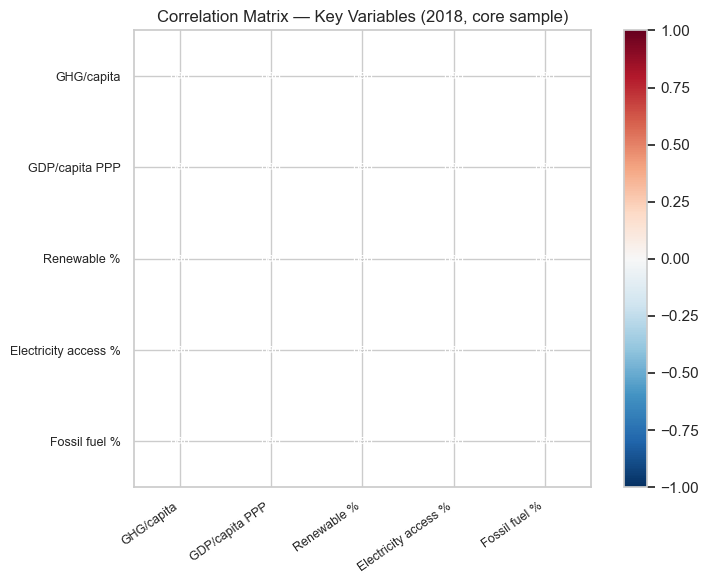

In [24]:
corr_vars = ['ghg_per_capita', 'gdp_per_capita_ppp', 'renewable_pct', 'electricity_access_pct', 'fossil_fuel_pct']
corr_labels = ['GHG/capita', 'GDP/capita PPP', 'Renewable %', 'Electricity access %', 'Fossil fuel %']

corr_data = data_2018[corr_vars].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(corr_labels, fontsize=9)

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='black' if abs(corr_matrix.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Correlation Matrix — Key Variables (2018, core sample)', fontsize=12)
plt.tight_layout()
#plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')

print('Saved: eda_correlation_matrix.png')

## 11. Export Clean Datasets

Three outputs are produced:

| File | Contents | Used by |
|------|----------|---------|
| `df_panel.csv` | Full joined panel (GHG + Economy + Energy, 2014–2020, all GHG countries) | Power BI (Viz 01, 02, 04, 05, 06, 08) |
| `df_core.csv` | Core analytical sample only (≥5 complete years) | Python Altair & D3.js Fingerprint (Viz 04, 07) |
| `df_trend.csv` | GHG-only, full 2014–2023 with % change | Slope chart / Racing bar (Viz 03) |
| `df_slope.csv` | One row per country: GHG 2014, 2023, % change | Slope chart (Viz 03a) |

In [25]:
# Add slope stats back to trend dataset
df_trend_out = df_trend.merge(
    df_slope[['iso3', 'ghg_change_pct', 'ghg_change_abs']],
    on='iso3', how='left'
)

# Export
df.to_csv('df_panel.csv', index=False)
df_core.to_csv('df_core.csv', index=False)
df_trend_out.to_csv('df_trend.csv', index=False)
df_slope.to_csv('df_slope.csv', index=False)

print('Exports complete:')
print(f'  df_panel.csv  — {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  df_core.csv   — {df_core.shape[0]:,} rows × {df_core.shape[1]} cols')
print(f'  df_trend.csv  — {df_trend_out.shape[0]:,} rows × {df_trend_out.shape[1]} cols')
print(f'  df_slope.csv  — {df_slope.shape[0]:,} rows × {df_slope.shape[1]} cols')

Exports complete:
  df_panel.csv  — 575 rows × 9 cols
  df_core.csv   — 525 rows × 12 cols
  df_trend.csv  — 789 rows × 7 cols
  df_slope.csv  — 44 rows × 7 cols


## 12. Limitations & Bias Summary

| Issue | Detail | Impact on Analysis |
|-------|--------|--------------------|
| **Temporal mismatch** | World Bank data ends at 2020; OECD GHG runs to 2023. The full 3-dataset panel is limited to 2014–2020. | Trend visualizations (Viz 03) use GHG alone (2014–2023); wealth and energy visualizations limited to 2014–2020. |
| **Geographic coverage** | Only ~81 countries have complete data across all 3 datasets. Sub-Saharan Africa (8 countries) and small island states are severely underrepresented. | Core findings may not generalize to the Global South; regional averages for Africa and South Asia are unreliable. |
| **LULUCF exclusion** | OECD GHG data excludes Land Use, Land Use Change and Forestry emissions by design (MEASURE = `_T`). | Net emissions of countries with heavy deforestation (e.g., Brazil, Indonesia) are systematically underestimated. |
| **Region variable constructed** | The `region` column is manually mapped from World Bank country metadata — it is absent from all three raw datasets. | Any error in the mapping propagates to all regional aggregations and the choropleth color encoding. |
| **Renewable energy definition** | World Bank's `renewable_pct` includes traditional biomass (wood, charcoal), common in low-income countries and associated with energy poverty rather than clean energy transition. | Some low-income countries may appear renewable-heavy for the wrong reason, distorting the "green by choice" classification in Viz 04. |
| **Correlation ≠ causation** | The project identifies empirical patterns only — no causal modeling of GDP → emissions or energy mix → emissions is attempted. | All findings must be framed as associations. The wealth–emissions relationship in Viz 02 does not imply that growth causes emissions. |
| **PPP vs nominal GDP** | GDP per capita PPP (current international $) adjusts for price levels but uses current rather than constant dollars, introducing inflation effects across years. | Year-over-year GDP comparisons in the animated scatter (Viz 02) partially reflect price-level changes, not only real growth. |


In [26]:
# Final summary
print('='*55)
print('PREPROCESSING COMPLETE — Summary')
print('='*55)
print(f'GHG countries (2014-2023):            {df_trend["iso3"].nunique()}')
print(f'Full panel countries (2014-2020):     {df["iso3"].nunique()}')
print(f'Core analytical sample:               {df_core["iso3"].nunique()}')
print(f'Slope chart countries (both endpoints): {len(df_slope)}')
print()
print('Output files:')
for f in ['df_panel.csv', 'df_core.csv', 'df_trend.csv', 'df_slope.csv']:
    print(f'  {f}')
print()
print('EDA charts:')
for f in ['eda_ghg_distribution.png', 'eda_scatter_gdp_ghg.png',
          'eda_ghg_trends.png', 'eda_choice_vs_poverty.png', 'eda_correlation_matrix.png']:
    print(f'  {f}')

PREPROCESSING COMPLETE — Summary
GHG countries (2014-2023):            90
Full panel countries (2014-2020):     90
Core analytical sample:               75
Slope chart countries (both endpoints): 44

Output files:
  df_panel.csv
  df_core.csv
  df_trend.csv
  df_slope.csv

EDA charts:
  eda_ghg_distribution.png
  eda_scatter_gdp_ghg.png
  eda_ghg_trends.png
  eda_choice_vs_poverty.png
  eda_correlation_matrix.png


## 13. Visualization-Dataset Mapping

The table below documents which cleaned output file feeds each visualization, to ensure reproducibility and make the Power BI / Python / JS development steps self-contained.

| Viz | Title | Tool | Input file | Key variables | Analytical question |
|-----|-------|------|------------|---------------|---------------------|
| 01 | Choropleth map | Power BI | `df_panel.csv` | `iso3`, `year`, `ghg_per_capita`, `region` | Where are emissions highest, and how has the global distribution shifted year by year from 2014 to 2020? Serves as the spatial entry point and cross-filtering hub for the whole dashboard. |
| 02 | Bubble scatter GDP vs GHG | Power BI | `df_panel.csv` | `gdp_per_capita_ppp`, `ghg_per_capita`, `region`, `year` | Do wealthier countries systematically emit more per capita? Which countries break the expected pattern — high income but low emissions, or low income but high emissions? |
| 03 | Slope chart 2014→2023 | Python (Plotly) | `df_slope.csv` | `ghg_2014`, `ghg_2023`, `ghg_change_pct`, `region` | Which countries have reduced their per-capita emissions the most over the decade, and which have worsened? Does improvement cluster by region or income level? |
| 04 | Diverging dot plot GHG vs renewables | Python (Altair) | `df_core.csv` | `ghg_per_capita`, `renewable_pct`, `region` | Is there a clean inverse relationship between renewable energy share and emissions? Do low-emission countries tend to have high renewables, or are other factors at play? |
| 05 | Country profile card | JavaScript | `df_core.csv` | all key variables, `country_name_ghg` | How does any single country compare to its regional and global averages across all four key dimensions simultaneously? Supports the deep-profile task for non-expert users. |
| 06 | Scatter electricity access vs GHG | Power BI | `df_panel.csv` | `electricity_access_pct`, `ghg_per_capita`, `region` | Are low-emission countries truly "clean", or are their low figures explained by limited electricity access and energy poverty rather than deliberate decarbonization? |
| 07 ★ | Radial Emission Fingerprint | D3.js | `df_core.csv` | `ghg_per_capita`, `gdp_per_capita_ppp`, `renewable_pct`, `electricity_access_pct` | What is the full four-variable "emissions profile" of a country, and how do up to four countries compare when all dimensions are shown simultaneously on a single radial form? |
| 08 | White hat / Black hat maps | Power BI | `df_panel.csv` | `iso3`, `ghg_per_capita` (per capita vs absolute) | How does the choice of metric — per capita vs total absolute emissions — produce opposite narratives from the same data, making small rich countries appear as villains or heroes depending on framing? |